# 02 — Shapes, in pictures

Hands-on companion to [`docs/02-shapes.md`](../docs/02-shapes.md).

Arrays enter the graph. We look at what a **broadcast** does to a gradient on the
way down, and at how `-` and `/` are built from the primitives we already trust.

> Run this with the notebook extra installed: `pip install -e ".[notebooks]"`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

from bonsaigrad import Leaf

# transparent figures, so they sit on whatever background is behind them
plt.rcParams["figure.facecolor"] = "none"
plt.rcParams["savefig.facecolor"] = "none"

### Drawing code

The same graph drawer as notebook 01, taught to handle arrays: a box now prints
its **values and shape** when it is small enough to read, and just its shape when
it is not. `_local_deriv` also learns `**k`, since `/` is built on it.

In [2]:
INK, MUTED, IDLE_EC = "#2f3437", "#9aa0a6", "#c9ccd1"
ROOT_FILL, OP_FILL = "#ffffff", "#f4f5f6"
FWD, FWD_FILL = "#3f6d8e", "#ecf2f7"      # values travelling up
BWD, BWD_FILL = "#c1543c", "#fdece7"      # gradient travelling down
SYM = {"+": "+", "*": "×"}


def _fmt(arr, shape=True):
    """Readable label for an array: values if they fit, otherwise just the shape."""
    if arr.ndim == 0:
        return f"{arr.item():.4g}"
    if arr.size > 6:
        return f"{arr.shape}"
    shown = np.array2string(arr, precision=3, separator=" ", suppress_small=True)
    shown = shown.replace(chr(10), "")
    return f"{shown}  {arr.shape}" if shape else shown


def _sym(op):
    """Mathtext symbol for an op label. ``**k`` reads better as an exponent."""
    if op.startswith("**"):
        return rf"(\cdot)^{{{op[2:]}}}"
    return SYM.get(op, op)


def _trace(apex):
    nodes, edges, seen = [], [], set()

    def walk(n):
        if id(n) in seen:
            return
        seen.add(id(n))
        nodes.append(n)
        for stem in n._stems:
            edges.append((stem, n))
            walk(stem)

    walk(apex)
    return nodes, edges


def _depth(node, memo):
    if id(node) in memo:
        return memo[id(node)]
    d = 0 if not node._stems else 1 + max(_depth(s, memo) for s in node._stems)
    memo[id(node)] = d
    return d


def _local_deriv(node, stem):
    """∂node/∂stem, or None when the edge just passes gradient through."""
    if node._op == "*":
        other = node._stems[0] if node._stems[1] is stem else node._stems[1]
        return other.data
    if node._op.startswith("**"):
        k = float(node._op[2:])
        return k * stem.data ** (k - 1)
    return None  # a `+` edge multiplies by 1 — labelling it says nothing


def _layout(nodes, edges):
    """Place nodes by depth, then reduce edge crossings by barycentre ordering."""
    memo, levels = {}, {}
    for n in nodes:
        levels.setdefault(_depth(n, memo), []).append(n)

    xs, shoots = {}, {}
    for stem, shoot in edges:
        shoots.setdefault(id(stem), []).append(shoot)
    for layer in levels.values():
        for i, n in enumerate(layer):
            xs[id(n)] = i - (len(layer) - 1) / 2

    for _ in range(4):
        for d in sorted(levels):
            if d == max(levels):
                continue
            levels[d].sort(key=lambda n: (
                sum(xs[id(sh)] for sh in shoots.get(id(n), [])) / len(shoots[id(n)])
                if shoots.get(id(n)) else xs[id(n)]))
            for i, n in enumerate(levels[d]):
                xs[id(n)] = i - (len(levels[d]) - 1) / 2

    return {id(n): (xs[id(n)], d) for d in levels for n in levels[d]}, max(levels), shoots


def draw_graph(apex, names=None, ax=None, title=None, edge_labels=False,
               fired=None, flow="down", xgap=1.5, ygap=1.25):
    """Draw the graph feeding ``apex``. See notebook 01 for the full docstring.

    ``xgap``/``ygap`` widen the spacing — array labels make for wide, tall boxes
    that would otherwise collide.
    """
    names, up = names or {}, flow == "up"
    nodes, edges = _trace(apex)
    pos, top, shoots = _layout(nodes, edges)
    pos = {k: (x * xgap, y * ygap) for k, (x, y) in pos.items()}
    accent, accent_fill = (FWD, FWD_FILL) if up else (BWD, BWD_FILL)

    if up:
        live_nodes = {id(n) for n in nodes}
    else:
        if fired is None:
            fired = {id(n) for n in nodes if n._stems} if apex.grad.any() else set()
        live_nodes = {id(n) for n in nodes if any(id(sh) in fired for sh in shoots.get(id(n), []))}
        if apex.grad.any():
            live_nodes.add(id(apex))

    if ax is None:
        _, ax = plt.subplots(figsize=(4.4 * xgap, 1.5 + 1.4 * top * ygap))

    for stem, shoot in edges:
        (x0, y0), (x1, y1) = pos[id(stem)], pos[id(shoot)]
        live = True if up else id(shoot) in fired
        tail, head = ((x0, y0), (x1, y1)) if up else ((x1, y1), (x0, y0))
        ax.add_patch(FancyArrowPatch(
            tail, head, arrowstyle="-|>", mutation_scale=11,
            color=accent if live else MUTED, lw=1.7 if live else 1.1,
            shrinkA=34, shrinkB=34, zorder=1))
        loc = _local_deriv(shoot, stem)
        if edge_labels and not up and loc is not None:
            dx, dy = x0 - x1, y0 - y1
            norm = (dx * dx + dy * dy) ** 0.5 or 1
            # midpoint for a one-level edge; an edge that skips a level is
            # labelled near its stem instead, clear of the boxes in between
            f = 0.5 if abs(dy) <= ygap * 1.01 else 0.72
            ax.text(x1 + f * dx - dy / norm * 0.26, y1 + f * dy + dx / norm * 0.26,
                    f"×{_fmt(loc, shape=False)}", fontsize=8.5, zorder=3,
                    color=accent if live else MUTED, ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="none"))

    for n in nodes:
        x, y = pos[id(n)]
        live, named = id(n) in live_nodes, names.get(id(n))
        head = f"{named} = {_sym(n._op)}" if named and n._stems \
            else named or _sym(n._op) if n._stems else named or "root"
        lines = [f"$\\bf{{{head}}}$", f"data  {_fmt(n.data)}"]
        if not up:
            gline = f"grad  {_fmt(n.grad)}"
            parts = shoots.get(id(n), [])
            if live and len(parts) > 1 and n.data.ndim == 0 \
                    and all(sh.data.ndim == 0 for sh in parts):
                terms = [sh.grad.item() * float(d if (d := _local_deriv(sh, n)) is not None else 1.0)
                         for sh in parts]
                if abs(sum(terms) - n.grad.item()) < 1e-9:  # only once every path has landed
                    gline += "   ({})".format(" + ".join(f"{t:.4g}" for t in terms))
            lines.append(gline)
        ax.text(x, y, "\n".join(lines),
                ha="center", va="center", fontsize=8.5, color=INK, linespacing=1.5, zorder=2,
                bbox=dict(boxstyle="round,pad=0.42", lw=1.7 if live else 1.1,
                          fc=(accent_fill if n._stems else ROOT_FILL) if live
                          else (OP_FILL if n._stems else ROOT_FILL),
                          ec=accent if live else IDLE_EC))

    xs = [p[0] for p in pos.values()]
    ax.set_xlim(min(xs) - xgap, max(xs) + xgap)
    ax.set_ylim(-0.6, top * ygap + 0.6)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=10.5, color=INK, pad=8)
    return ax

## How broadcasting works

What NumPy does when the shapes disagree, before any gradients are involved.

Align the shapes **from the right**, pad the shorter one with `1`s on the left, and
stretch every length-`1` axis to match the other. Two axes are compatible when they
are equal, or when one of them is `1`. Padding is the same rule with an implicit
`1`.

The cell below applies the rule and prints its working, including one pair that
does not broadcast.

In [3]:
pairs = [
    ((4, 3),    (3,),    "matrix + row vector"),
    ((4, 3),    (4, 1),  "matrix × column vector"),
    ((3, 1),    (1, 4),  "outer product — both stretch"),
    ((4, 3),    (),      "matrix × scalar"),
    ((8, 4, 3), (3,),    "stack of matrices + row vector"),
    ((2, 3),    (2,),    "incompatible: the 2 aligns under the 3"),
    ((2, 3),    (2, 1),  "fixed: the 1 aligns under the 3"),
]

for sa, sb, note in pairs:
    nd = max(len(sa), len(sb))
    pa, pb = (1,) * (nd - len(sa)) + sa, (1,) * (nd - len(sb)) + sb   # pad on the left
    try:
        out = (np.zeros(sa) + np.zeros(sb)).shape   # the real op, for the real message
        # an axis is stretched where the padded shape says 1 but the output says more
        stretch_a = [i for i, (p, o) in enumerate(zip(pa, out)) if p == 1 and o > 1]
        stretch_b = [i for i, (p, o) in enumerate(zip(pb, out)) if p == 1 and o > 1]
        print(f"{str(sa):11} ∘ {str(sb):9} → {str(out):11}"
              f" stretched  a{str(stretch_a):7} b{str(stretch_b):7}  {note}")
    except ValueError as e:
        print(f"{str(sa):11} ∘ {str(sb):9} → ValueError: {e}".rstrip())
        print(f"{'':11}   padded: a{pa}  b{pb} — the {sb[-1]} lands under the "
              f"{sa[-1]}, not under the {sa[0]}")

(4, 3)      ∘ (3,)      → (4, 3)      stretched  a[]      b[0]      matrix + row vector
(4, 3)      ∘ (4, 1)    → (4, 3)      stretched  a[]      b[1]      matrix × column vector
(3, 1)      ∘ (1, 4)    → (3, 4)      stretched  a[1]     b[0]      outer product — both stretch
(4, 3)      ∘ ()        → (4, 3)      stretched  a[]      b[0, 1]   matrix × scalar
(8, 4, 3)   ∘ (3,)      → (8, 4, 3)   stretched  a[]      b[0, 1]   stack of matrices + row vector
(2, 3)      ∘ (2,)      → ValueError: operands could not be broadcast together with shapes (2,3) (2,)
              padded: a(2, 3)  b(1, 2) — the 2 lands under the 3, not under the 2
(2, 3)      ∘ (2, 1)    → (2, 3)      stretched  a[]      b[1]      fixed: the 1 aligns under the 3


### Stretching is free

`strides` says how many bytes to step to move one index along each axis. Stretching
an axis sets its stride to **zero**: every index along that axis reads the same
memory.

The wide arrays below are views, not data. Solid cells are real numbers; dashed
cells are the same bytes read again. No copy exists in memory — but each dashed cell
is a **use**, and the backward pass owes one gradient term per use, not per
byte.

a  shape (3, 1)  strides (8, 8)   24 bytes
b  shape (1, 4)  strides (32, 8)   32 bytes
broadcast_to(a, (3, 4))  strides (8, 0)   base is a: True   claims 96 bytes
broadcast_to(b, (3, 4))  strides (0, 8)   base is b: True   claims 96 bytes


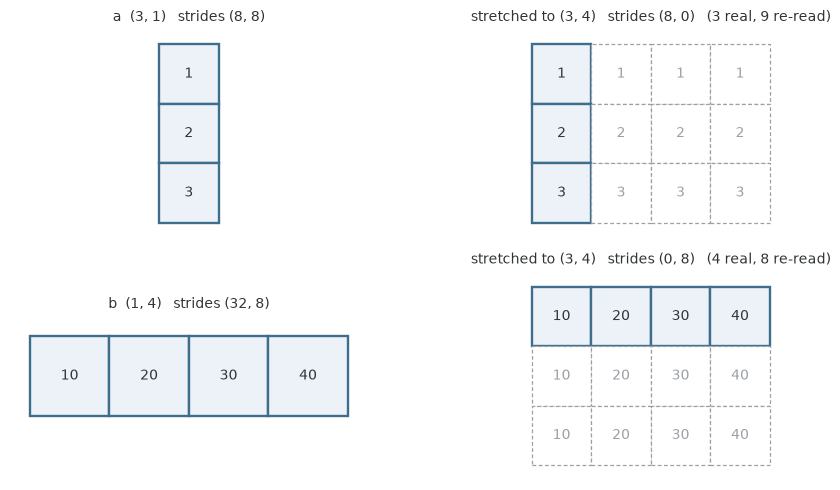

In [4]:
a = np.array([[1.0], [2.0], [3.0]])            # (3, 1)
b = np.array([[10.0, 20.0, 30.0, 40.0]])       # (1, 4)

print(f"a  shape {a.shape}  strides {a.strides}   {a.nbytes} bytes")
print(f"b  shape {b.shape}  strides {b.strides}   {b.nbytes} bytes")
for name, arr in (("a", a), ("b", b)):
    view = np.broadcast_to(arr, (3, 4))
    print(f"broadcast_to({name}, (3, 4))  strides {view.strides}"
          f"   base is {name}: {view.base is arr}   claims {view.nbytes} bytes")


def cell_grid(ax, values, real, color, fill, title):
    """Draw an array; ``real`` marks the cells that are actual memory."""
    rows, cols = values.shape
    for (i, j), v in np.ndenumerate(values):
        solid = real[i, j]
        ax.add_patch(Rectangle((j, -i), 1, 1, fc=fill if solid else "#ffffff",
                               ec=color if solid else MUTED, lw=1.7 if solid else 0.9,
                               ls="-" if solid else (0, (3, 2))))
        ax.text(j + 0.5, -i + 0.5, f"{v:g}", ha="center", va="center", fontsize=10,
                color=INK if solid else MUTED)
    ax.set_xlim(-0.25, cols + 0.25)
    ax.set_ylim(-rows + 0.75, 1.25)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=10, color=INK, pad=6)


fig, axes = plt.subplots(2, 2, figsize=(11, 5), width_ratios=[1, 2.4])

for row, (name, arr) in enumerate((("a", a), ("b", b))):
    wide = np.broadcast_to(arr, (3, 4))
    real = np.zeros((3, 4), dtype=bool)
    real[:arr.shape[0], :arr.shape[1]] = True     # the one row / column that exists
    cell_grid(axes[row][0], arr, np.ones_like(arr, dtype=bool), FWD, FWD_FILL,
              f"{name}  {arr.shape}   strides {arr.strides}")
    cell_grid(axes[row][1], wide, real, FWD, FWD_FILL,
              f"stretched to {wide.shape}   strides {wide.strides}"
              f"   ({real.sum()} real, {(~real).sum()} re-read)")

plt.tight_layout()
plt.show()

### Copy up, sum down

A broadcast only *copies* entries — it never scales or mixes them. That makes it a
**linear** map, and for a linear map the backward pass is its transpose. The
transpose of "copy one value into 4 slots" is "sum those 4 slots back into one":

```
forward:   stretch an axis   (one value  → many)
backward:  sum along it      (many grads → one)
```

This is 01's `+=` rule again, now at scale: each dashed cell above is a path, and
a node's
gradient is the sum over its paths.

### Sum, not average

The number of copies does not divide the gradient. A row vector `v` used once per
row of an `n`-row matrix, each time with local derivative `1`, moves the output by
`n·ε` when it moves by `ε`. Its gradient is `n`.

`wire` seeds the apex with ones, so it differentiates the **sum**. The mean is a
different function: write the `/ n` into the expression and the `1/n` appears in the
gradient because the graph contains it.

In [5]:
row = np.array([1.0, -2.0, 0.5])

for n in (1, 4, 16):
    m, v = Leaf(np.tile(row, (n, 1))), Leaf(np.ones(3))
    (m * v).wire()                       # gradient of the summed output
    m_mean, v_mean = Leaf(np.tile(row, (n, 1))), Leaf(np.ones(3))
    (m_mean * v_mean / n).wire()         # …of the mean, with the /n written down
    print(f"n = {n:2}   summed v.grad {np.round(v.grad, 3)}"
          f"      mean v.grad {np.round(v_mean.grad, 3)}")
    np.testing.assert_allclose(v.grad, n * row)
    np.testing.assert_allclose(v_mean.grad, row)

print("\nThe summed gradient scales with the row count; the averaged one does not.")
print("Nothing divides by n unless the division is in the graph.")

n =  1   summed v.grad [ 1.  -2.   0.5]      mean v.grad [ 1.  -2.   0.5]
n =  4   summed v.grad [ 4. -8.  2.]      mean v.grad [ 1.  -2.   0.5]
n = 16   summed v.grad [ 16. -32.   8.]      mean v.grad [ 1.  -2.   0.5]

The summed gradient scales with the row count; the averaged one does not.
Nothing divides by n unless the division is in the graph.


## A scalar feeding a vector

`Leaf(3.0) * Leaf([1.0, 2.0])`. Nothing surprising happens going up — NumPy
stretches the scalar. Coming down is where the shapes clash: `out.grad` has shape
`(2,)`, but `a.grad` must stay a single number.

Read the two `grad` lines on the right. `b` gets one gradient entry per entry,
while `a` gets the **sum** of the two — one term for each copy of it that NumPy
made. Before `_unbroadcast`, this exact graph raised
`ValueError: non-broadcastable output operand`.

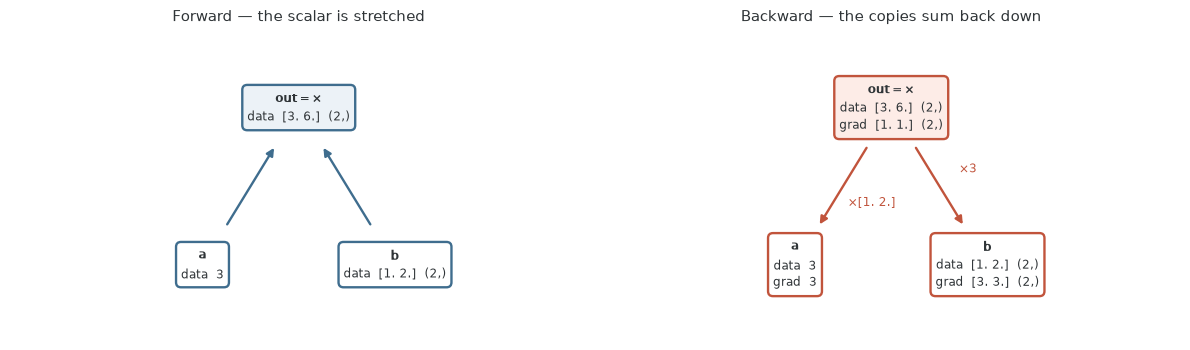

a.data ()  →  a.grad () = 3.0   (1.0 + 2.0)
b.data (2,)  →  b.grad (2,) = [3. 3.]


In [6]:
a, b = Leaf(3.0), Leaf([1.0, 2.0])
out = a * b
names = {id(a): "a", id(b): "b", id(out): "out"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.6))
draw_graph(out, names, ax=ax1, title="Forward — the scalar is stretched", flow="up")
out.wire()
draw_graph(out, names, ax=ax2, title="Backward — the copies sum back down", edge_labels=True)
plt.tight_layout()
plt.show()

print(f"a.data {a.data.shape}  →  a.grad {a.grad.shape} = {a.grad}   (1.0 + 2.0)")
print(f"b.data {b.data.shape}  →  b.grad {b.grad.shape} = {b.grad}")

## Forward copies, backward sums

The rule in one picture. `out = a + b` with `a` of shape `(3, 1)` and `b` of shape
`(1, 4)`, so `out` is `(3, 4)` — twelve entries grown from seven numbers.

**Left:** each entry of `a` is copied along a whole **row**, each entry of `b`
down a whole **column**. **Right:** `wire` seeds `out.grad` with ones, and each
input collects the entries it fed — `a` by summing rows, `b` by summing columns.
That is `_unbroadcast`: sum over the axes that were stretched, keeping the axis
itself so the shape still matches.

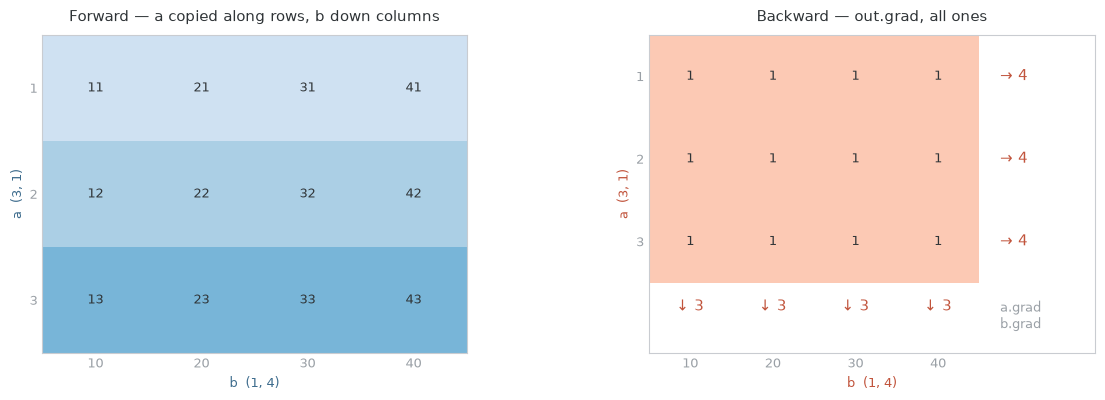

a.grad (3, 1) = [4. 4. 4.]  each entry fed 4 outputs
b.grad (1, 4) = [3. 3. 3. 3.]  each entry fed 3 outputs


In [7]:
a = Leaf([[1.0], [2.0], [3.0]])
b = Leaf([[10.0, 20.0, 30.0, 40.0]])
out = a + b
out.wire()

rows, cols = out.data.shape
bands = np.tile(np.arange(rows)[:, None], (1, cols))  # shade by row: a's copies

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.1))

for ax, grid, shade, accent, cmap, title in [
    (ax1, out.data, bands, FWD, "Blues", "Forward — a copied along rows, b down columns"),
    (ax2, out.grad, np.zeros_like(out.grad), BWD, "Reds", "Backward — out.grad, all ones"),
]:
    ax.imshow(shade, cmap=cmap, vmin=-1.5, vmax=rows + 3)
    for (i, j), v in np.ndenumerate(grid):
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9.5, color=INK)
    ax.set_xticks(range(cols), [f"{v:.0f}" for v in b.data[0]])
    ax.set_yticks(range(rows), [f"{v:.0f}" for v in a.data[:, 0]])
    ax.set_xlabel(f"b  {b.data.shape}", color=accent, fontsize=9)
    ax.set_ylabel(f"a  {a.data.shape}", color=accent, fontsize=9)
    ax.set_title(title, fontsize=10.5, color=INK, pad=10)
    ax.tick_params(length=0, labelsize=9, colors=MUTED)
    for s in ax.spines.values():
        s.set_color(IDLE_EC)

# marginal sums: rows collapse into a.grad, columns into b.grad
for i, g in enumerate(a.grad[:, 0]):
    ax2.text(cols - 0.25, i, f"→ {g:.0f}", ha="left", va="center", fontsize=10.5, color=BWD)
for j, g in enumerate(b.grad[0]):
    ax2.text(j, rows - 0.3, f"↓ {g:.0f}", ha="center", va="top", fontsize=10.5, color=BWD)
ax2.text(cols - 0.25, rows - 0.3, "a.grad\nb.grad", ha="left", va="top", fontsize=9, color=MUTED)
ax2.set_xlim(-0.5, cols + 0.9)
ax2.set_ylim(rows + 0.35, -0.5)

plt.tight_layout()
plt.show()

print(f"a.grad {a.grad.shape} =", a.grad.ravel(), " each entry fed 4 outputs")
print(f"b.grad {b.grad.shape} =", b.grad.ravel(), " each entry fed 3 outputs")

## The invariant

Whatever the shapes going in, every node comes out with `grad.shape ==
data.shape`. That is what makes `data -= lr * grad` meaningful later on, so it is
worth checking across the patterns above.

In [8]:
cases = [
    ("scalar × vector",         lambda: (Leaf(3.0), Leaf([1.0, 2.0]))),
    ("matrix + row vector",     lambda: (Leaf(np.ones((4, 3))), Leaf([1.0, 2.0, 3.0]))),
    ("column × row",            lambda: (Leaf(np.ones((3, 1))), Leaf(np.ones((1, 4))))),
    ("matrix × column vector",  lambda: (Leaf(np.ones((4, 3))), Leaf(np.ones((4, 1))))),
]

for label, make in cases:
    x, y = make()
    (x * y).wire()
    ok = x.grad.shape == x.data.shape and y.grad.shape == y.data.shape
    print(f"{label:22} {str(x.data.shape):8} ∘ {str(y.data.shape):8}"
          f" → grads {str(x.grad.shape):8} {str(y.grad.shape):8} {'✓' if ok else '✗'}")
    assert ok

scalar × vector        ()       ∘ (2,)     → grads ()       (2,)     ✓
matrix + row vector    (4, 3)   ∘ (3,)     → grads (4, 3)   (3,)     ✓
column × row           (3, 1)   ∘ (1, 4)   → grads (3, 1)   (1, 4)   ✓
matrix × column vector (4, 3)   ∘ (4, 1)   → grads (4, 3)   (4, 1)   ✓
